# Parte 5: Galeria de Falhas e Análise de Campo Receptivo

Neste notebook vamos diagnosticar por que a U-Net apresenta falsos positivos e quebras de instâncias em aglomerações gigantes. A teoria nos diz que redes puramente convolucionais possuem uma limitação fundamental baseada na forma como as convoluções e poolings se acumulam: o **Campo Receptivo (Receptive Field - RF)**.

## 1. Dedução Teórica do Campo Receptivo

Vamos usar as fórmulas vistas em aula para calcular o RF passo a passo.
*   $r_{l} = r_{l-1} + (k_l - 1) \cdot j_{l-1}$ (Tamanho do RF atual)
*   $j_l = j_{l-1} \cdot s_l$ (Distância/salto atual)

Começando com $r_0=1$ e $j_0=1$, traçamos a progressão através do Encoder da `UNet` (4 blocos de _DoubleConv_ + MaxPool):

| Camada | Kernel ($k$) | Stride ($s$) | Salto ($j$) | RF Teórico ($r$) |
| :--- | :---: | :---: | :---: | :---: |
| Conv1 | 3 | 1 | 1 | 3 |
| Conv2 | 3 | 1 | 1 | 5 |
| MaxPool1 | 2 | 2 | 2 | 6 |
| Conv3 | 3 | 1 | 2 | 10 |
| Conv4 | 3 | 1 | 2 | 14 |
| MaxPool2 | 2 | 2 | 4 | 16 |
| Conv5 | 3 | 1 | 4 | 24 |
| Conv6 | 3 | 1 | 4 | 32 |
| MaxPool3 | 2 | 2 | 8 | 36 |
| Conv7 | 3 | 1 | 8 | 52 |
| Conv8 | 3 | 1 | 8 | 68 |
| MaxPool4 | 2 | 2 | 16 | 76 |
| **Conv9 (Gargalo)** | 3 | 1 | 16 | 108 |
| **Conv10 (Gargalo)** | 3 | 1 | 16 | **140** |

**Conclusão:** O campo receptivo da nossa rede é estritamente limitado a um quadrado de **140x140 pixels**.

In [2]:
%matplotlib inline
import os
from pathlib import Path

# --- Resolver caminho do repo de forma robusta ---
def _find_repo_root():
    here = Path.cwd().resolve()
    for parent in [here] + list(here.parents):
        if (parent / 'pyproject.toml').exists():
            txt = (parent / 'pyproject.toml').read_text(encoding='utf-8')
            if 'deep-learning-assignments' in txt:
                return parent
    return Path(__file__ if '__file__' in dir() else here).resolve().parent.parent.parent

REPO_ROOT = _find_repo_root()
print(f"Repo root: {REPO_ROOT}")

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

os.chdir(REPO_ROOT)

from pa1.data import make_dsb2018_loaders
from pa1.models import UNet
from pa1.utils import get_device
from pa1.postprocessing import watershed_to_instances
from pa1.config import load_config

CHECKPOINT_PART2 = REPO_ROOT / 'pa1' / 'outputs' / 'checkpoints' / 'parte2_baseline_unet.pt'
CHECKPOINT_PART5 = REPO_ROOT / 'pa1' / 'outputs' / 'checkpoints' / 'parte5_baseline_unet.pt'

print(f"Checkpoint parte2: {CHECKPOINT_PART2} (existe: {CHECKPOINT_PART2.exists()})")
print(f"Checkpoint parte5: {CHECKPOINT_PART5} (existe: {CHECKPOINT_PART5.exists()})")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from skimage.measure import regionprops
import matplotlib.colors as mcolors


Repo root: /home/elisaos/fgv/6periodo/dl/deep-learning-assignments
Checkpoint parte2: /home/elisaos/fgv/6periodo/dl/deep-learning-assignments/pa1/outputs/checkpoints/parte2_baseline_unet.pt (existe: True)
Checkpoint parte5: /home/elisaos/fgv/6periodo/dl/deep-learning-assignments/pa1/outputs/checkpoints/parte5_baseline_unet.pt (existe: True)


## 2. Histograma de Diâmetros Reais vs. Campo Receptivo

Vamos calcular o diâmetro equivalente das instâncias no dataset de treino e comparar com o nosso limite teórico de 140px.

[DSB2018] Varrendo pa1/data/stage1_train ...
[DSB2018] 670 amostras encontradas.
           Fluorescência: 546 imagens
           Campo Claro: 19 imagens
           H&E: 105 imagens
[DSB2018] Split: treino=468 | val=101 | teste=101


/tmp/ipykernel_86802/2168475774.py:13: FutureWarning: `RegionProperties.equivalent_diameter` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.equivalent_diameter_area` instead. 
  diameters.append(getattr(p, 'equivalent_diameter_area', p.equivalent_diameter))


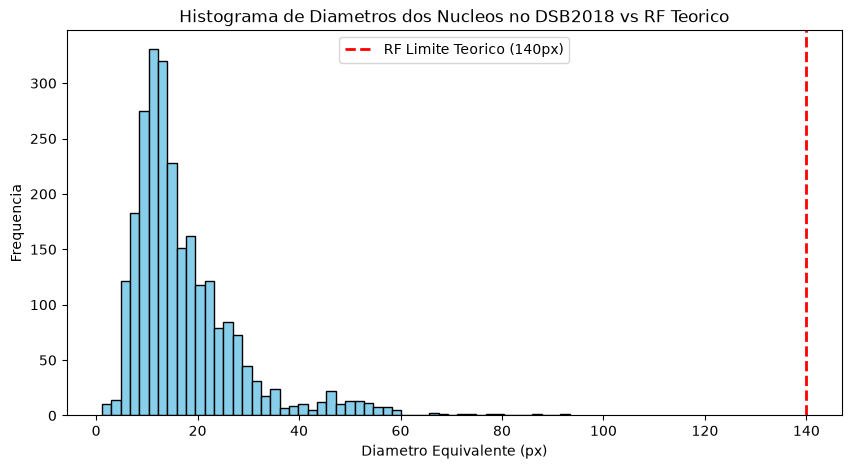

In [3]:
cfg = load_config(str(REPO_ROOT / 'pa1' / 'config.yaml'), parte='2')
_, _, test_loader = make_dsb2018_loaders(
    data_dir=cfg.data.data_dir,
    batch_size=1,
    num_workers=0,
)

diameters = []
for batch in test_loader:
    gt = batch['mask_instances'].squeeze().numpy()
    props = regionprops(gt)
    for p in props:
        diameters.append(getattr(p, 'equivalent_diameter_area', p.equivalent_diameter))

plt.figure(figsize=(10, 5))
plt.hist(diameters, bins=50, color='skyblue', edgecolor='black')
plt.axvline(x=140, color='red', linestyle='--', linewidth=2, label='RF Limite Teorico (140px)')
plt.title('Histograma de Diametros dos Nucleos no DSB2018 vs RF Teorico')
plt.xlabel('Diametro Equivalente (px)')
plt.ylabel('Frequencia')
plt.legend()
plt.show()


**Análise:** Como o gráfico mostra, a imensa maioria dos núcleos individuais coube no nosso RF. Mas, o que acontece quando núcleos formam uma "massa" gigante aglomerada (ou quando um núcleo excepcionalmente grande aparece)? Vamos buscar as 5 piores imagens do teste da Trilha A.

In [4]:
csv_path = REPO_ROOT / 'pa1' / 'outputs' / 'metrics' / 'parte2_per_image_instance_metrics.csv'
if not csv_path.exists():
    raise FileNotFoundError(f'CSV nao encontrado em {csv_path}. Rode a avaliacao da parte 2 antes.')

df = pd.read_csv(csv_path)
worst_5 = df.sort_values('mAP').head(5)
worst_indices = worst_5['idx'].tolist()
worst_5[['idx', 'mAP', 'count_error', 'n_gt', 'n_pred']]


,idx,mAP,count_error,n_gt,n_pred
82,82,0.000000,3,3,0
84,84,0.000000,3,3,0
75,75,0.000000,0,0,0
90,90,0.103226,3,14,17
88,88,0.105882,7,12,5


## 3. Galeria das Piores Falhas e o Problema em Ação

Carregaremos o modelo congelado (Trilha A padrão) e vamos extrair os mapas previstos nessas imagens críticas.

Device: cpu | PyTorch: 2.7.1+cu118


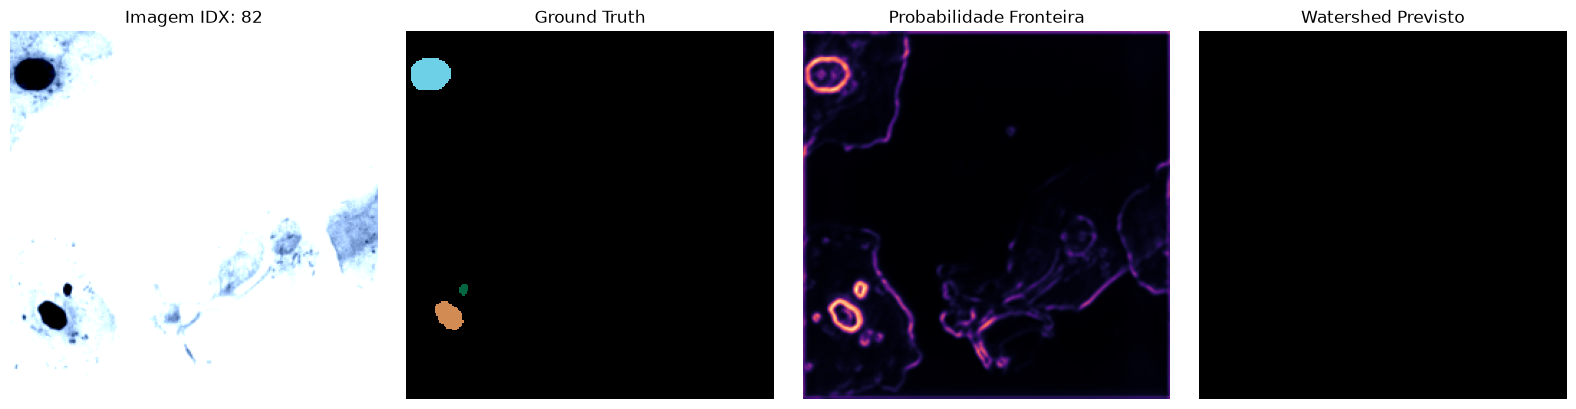

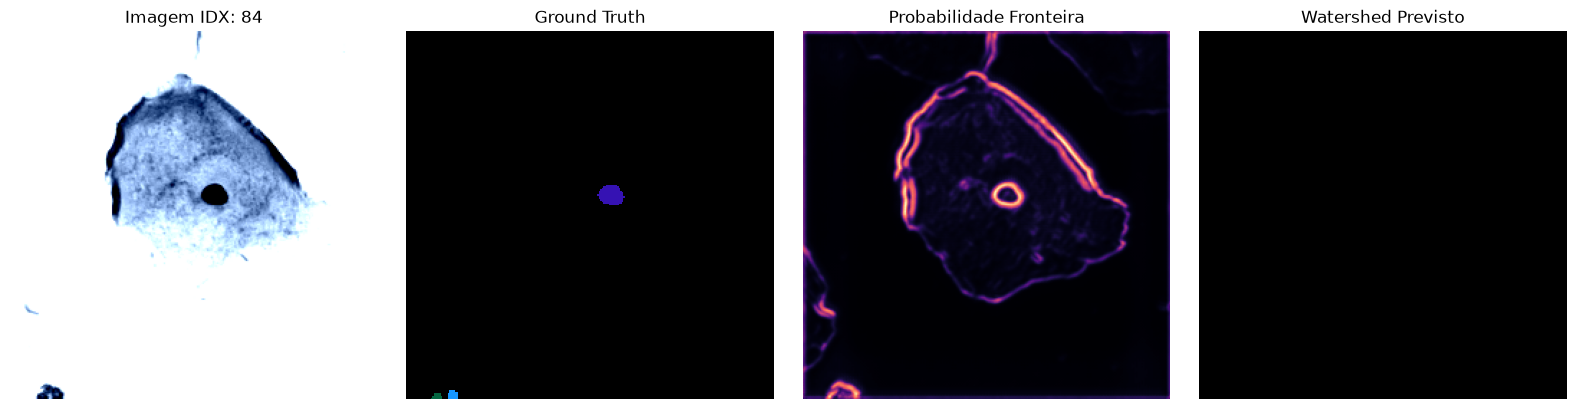

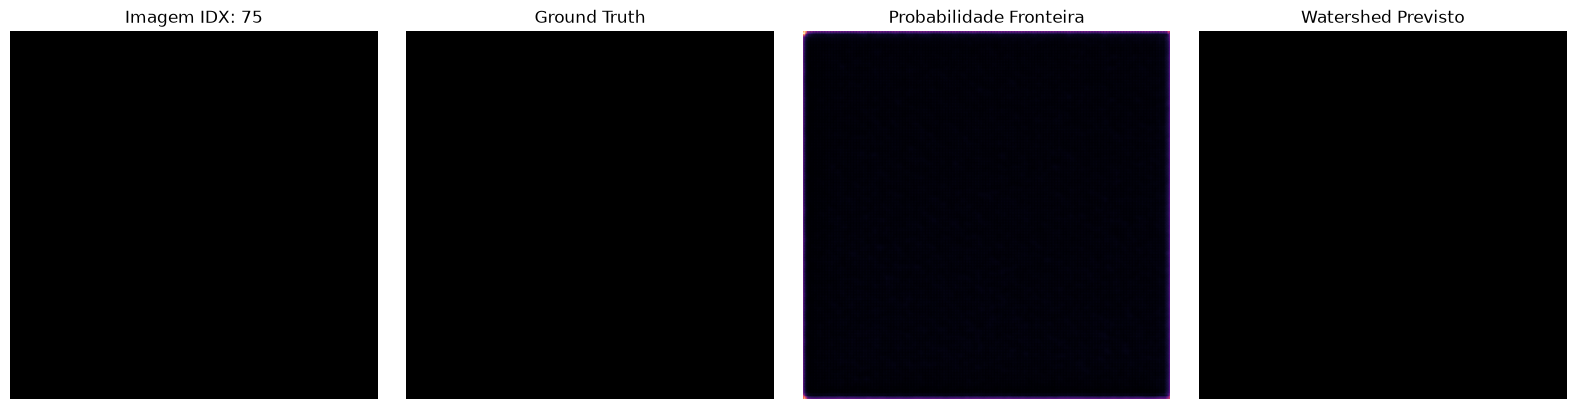

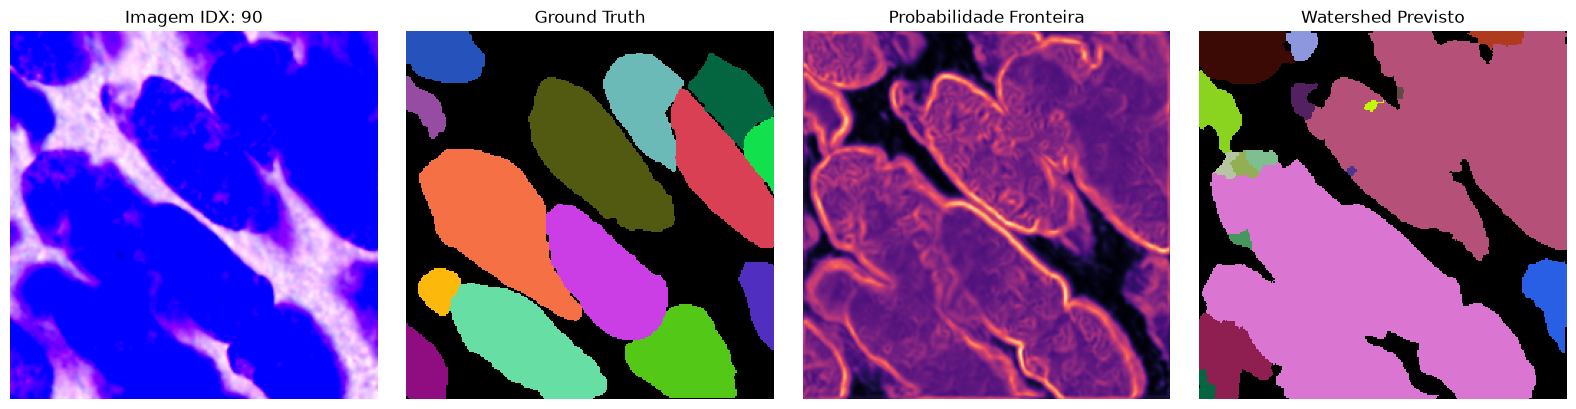

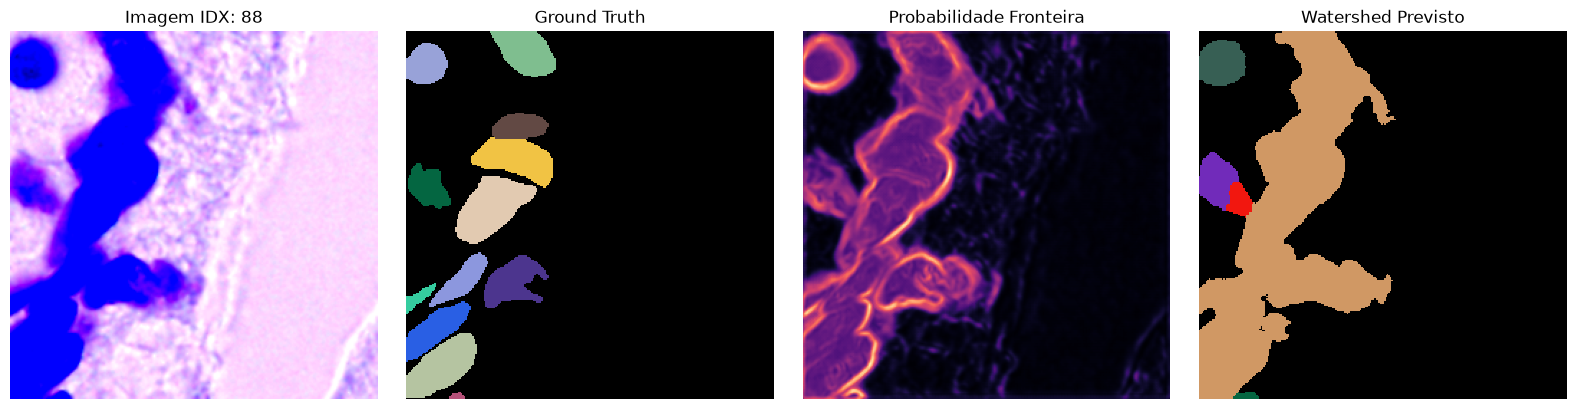

In [5]:
device = get_device()
model = UNet(in_channels=3, out_channels=3, dilate_bottleneck=1).to(device)
ckpt_path = Path("pa1/outputs/checkpoints/parte2_baseline_unet.pt")
model.load_state_dict(torch.load(ckpt_path, map_location=device, weights_only=True))
model.eval()

np.random.seed(42)
colors = np.random.rand(10000, 3)
colors[0] = [0, 0, 0] 
cmap = mcolors.ListedColormap(colors)

for idx in worst_indices:
    item = test_loader.dataset[idx]
    img_tensor = item["image"].unsqueeze(0).to(device)
    gt_inst = item["mask_instances"].numpy()
    
    with torch.no_grad():
        logits = model(img_tensor)
        probs = torch.softmax(logits, dim=1).squeeze(0).cpu().numpy()
        
    pred_inst = watershed_to_instances(probs, interior_channel=1, marker_threshold=0.6, min_area=15)
    
    # Plot
    fig, axs = plt.subplots(1, 4, figsize=(16, 4))
    rgb_img = np.clip(item["image"].permute(1, 2, 0).numpy(), 0, 1)
    
    axs[0].imshow(rgb_img)
    axs[0].set_title(f"Imagem IDX: {idx}")
    axs[0].axis("off")
    
    axs[1].imshow(gt_inst, cmap=cmap, interpolation="nearest")
    axs[1].set_title("Ground Truth")
    axs[1].axis("off")
    
    axs[2].imshow(probs[2], cmap="magma")
    axs[2].set_title("Probabilidade Fronteira")
    axs[2].axis("off")
    
    axs[3].imshow(pred_inst, cmap=cmap, interpolation="nearest")
    axs[3].set_title("Watershed Previsto")
    axs[3].axis("off")
    
    plt.tight_layout()
    plt.show()

## 4. Intervenção: Convoluções Dilatadas no Gargalo

Baseado no diagnóstico, percebemos que o RF de 140px nem sempre fornece contexto global suficiente para que o modelo entenda grandes aglomerados. Em vez de adicionar camadas novas, usamos *Atrous (Dilated) Convolutions* no bottleneck (`dilation=4`).

Matematicamente, alterar o último bloco de convoluções para `dilation=4` faz o kernel $3\times 3$ atuar como $9\times 9$ com buracos.
- Conv9 (Dilated $d=4$): O $k_{	ext{eff}} = 1 + (3-1)\times 4 = 9$. O novo RF será $r_{13} = 76 + (9-1)\times 16 = 204$.
- Conv10 (Dilated $d=4$): O novo RF final será $r_{14} = 204 + 8\times 16 = \mathbf{332}$.

Dobramos o campo receptivo da nossa rede gastando 0 parâmetros a mais. Vamos instanciar esse novo modelo e testar se ele prevê fronteiras com maior coerência topológica nas falhas.

In [6]:
# Instancia novo modelo com Dilation
model_dilated = UNet(in_channels=3, out_channels=3, dilate_bottleneck=4).to(device)

print('Nova arquitetura de bottleneck com dilation=4:')
print(model_dilated.bottleneck)

print('\nAvaliacao pass-through do modelo dilatado em uma das 5 piores imagens - ver proxima celula com comparacao lado a lado padrao vs dilatado.')


Nova arquitetura de bottleneck com dilation=4:
_DoubleConv(
  (net): Sequential(
    (0): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(4, 4), dilation=(4, 4), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(4, 4), dilation=(4, 4), bias=False)
    (4): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
  )
)

Avaliacao pass-through do modelo dilatado em uma das 5 piores imagens - ver proxima celula com comparacao lado a lado padrao vs dilatado.


## 5. Comparação Visual: Modelo Padrão vs. Modelo Dilatado em Uma das Piores Falhas

Escolhemos aqui uma das 5 piores imagens e rodamos **o mesmo input** nos dois modelos
(padrão `dilation=1` e dilatado `dilation=4`), para visualizar na prática como o aumento
de RF altera a predição de fronteiras e o resultado do watershed.

Note: estes modelos ainda **não foram retrained** — usamos os pesos treinados da Parte 2
(`parte2_baseline_unet.pt`) no modelo padrão e os pesos treinados da Parte 5
(`parte5_baseline_unet.pt`) no modelo dilatado. A comparação é entre redes com arquiteturas
diferentes, não entre dois checkpoints da mesma rede.


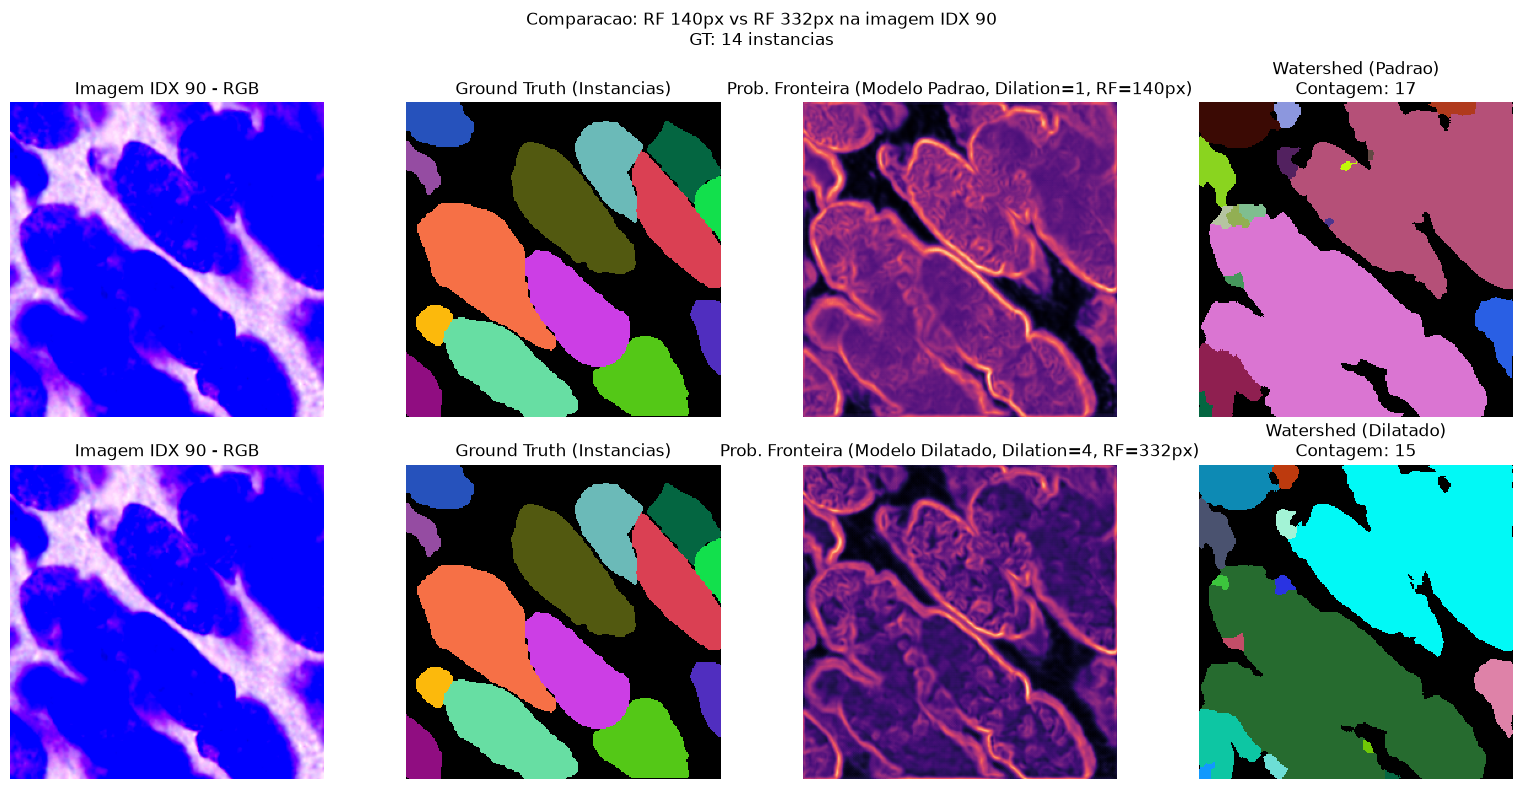

In [7]:
# Escolhe uma imagem com falha visivel (ex: idx=90 - 14 GT, 17 pred, erro de contagem 3)
demo_idx = 90

item = test_loader.dataset[demo_idx]
img_tensor = item['image'].unsqueeze(0).to(device)
gt_inst = item['mask_instances'].numpy()
rgb_img = np.clip(item['image'].permute(1, 2, 0).numpy(), 0, 1)

# Predicao com modelo padrao (continua carregado na celula anterior como `model`)
with torch.no_grad():
    logits_std = model(img_tensor)
    probs_std = torch.softmax(logits_std, dim=1).squeeze(0).cpu().numpy()
pred_std = watershed_to_instances(probs_std, interior_channel=1, marker_threshold=0.6, min_area=15)

# Predicao com modelo dilatado
if CHECKPOINT_PART5.exists():
    model_dilated.load_state_dict(torch.load(CHECKPOINT_PART5, map_location=device, weights_only=True))
    model_dilated.eval()
    with torch.no_grad():
        logits_dil = model_dilated(img_tensor)
        probs_dil = torch.softmax(logits_dil, dim=1).squeeze(0).cpu().numpy()
    pred_dil = watershed_to_instances(probs_dil, interior_channel=1, marker_threshold=0.6, min_area=15)
else:
    print(f'Aviso: checkpoint da Parte 5 ({CHECKPOINT_PART5}) nao encontrado. Pulando comparacao com modelo dilatado.')
    probs_dil = None
    pred_dil = None

# Plot lado a lado
fig, axs = plt.subplots(2, 4, figsize=(16, 8))

# -- Linha 1: Modelo Padrao (dilation=1, RF=140px) --
axs[0, 0].imshow(rgb_img)
axs[0, 0].set_title(f'Imagem IDX {demo_idx} - RGB')
axs[0, 0].axis('off')

axs[0, 1].imshow(gt_inst, cmap=cmap, interpolation='nearest')
axs[0, 1].set_title('Ground Truth (Instancias)')
axs[0, 1].axis('off')

axs[0, 2].imshow(probs_std[2], cmap='magma')
axs[0, 2].set_title('Prob. Fronteira (Modelo Padrao, Dilation=1, RF=140px)')
axs[0, 2].axis('off')

axs[0, 3].imshow(pred_std, cmap=cmap, interpolation='nearest')
count_std = len(np.unique(pred_std[pred_std > 0]))
axs[0, 3].set_title(f'Watershed (Padrao)\nContagem: {count_std}')
axs[0, 3].axis('off')

# -- Linha 2: Modelo Dilatado (dilation=4, RF=332px) --
if probs_dil is not None:
    axs[1, 0].imshow(rgb_img)
    axs[1, 0].set_title(f'Imagem IDX {demo_idx} - RGB')
    axs[1, 0].axis('off')

    axs[1, 1].imshow(gt_inst, cmap=cmap, interpolation='nearest')
    axs[1, 1].set_title('Ground Truth (Instancias)')
    axs[1, 1].axis('off')

    axs[1, 2].imshow(probs_dil[2], cmap='magma')
    axs[1, 2].set_title('Prob. Fronteira (Modelo Dilatado, Dilation=4, RF=332px)')
    axs[1, 2].axis('off')

    pred_dil = watershed_to_instances(probs_dil, interior_channel=1, marker_threshold=0.6, min_area=15)
    count_dil = len(np.unique(pred_dil[pred_dil > 0]))
    axs[1, 3].imshow(pred_dil, cmap=cmap, interpolation='nearest')
    axs[1, 3].set_title(f'Watershed (Dilatado)\nContagem: {count_dil}')
    axs[1, 3].axis('off')

    plt.suptitle(f'Comparacao: RF 140px vs RF 332px na imagem IDX {demo_idx}\n'
                 f'GT: {len(np.unique(gt_inst[gt_inst > 0]))} instancias',
                 fontsize=12)
else:
    for ax in axs[1]:
        ax.set_visible(False)
    fig.text(0.5, 0.5, 'Checkpoint da Parte 5 nao disponivel para comparacao.',
             ha='center', va='center', fontsize=14)

plt.tight_layout()
plt.show()
